# Phase 2 — Patient-Specific Fine-Tuned Model Evaluation (chb15)

This notebook evaluates the **patient-dependent fine-tuned model** for patient `chb15`.  
It loads the fine-tuned checkpoint (`patient_specific_model.pth`), rebuilds the chronological calibration/test split, runs streaming inference on the held-out test set, and reports full clinical metrics.

**Contents:**
1. Setup & Configuration
2. Load Fine-Tuned Checkpoint
3. Build Calibration / Test Split
4. Normalize & Prepare Test Data
5. Streaming Inference
6. Clinical Metrics (multi-threshold sweep)
7. Confusion Matrix & Visualizations
8. Comparison: Patient-Independent vs Fine-Tuned
9. Inference Latency Analysis

---
## 1. Setup & Configuration

In [1]:
import os, sys
import time
import warnings
warnings.filterwarnings('ignore')

# Ensure project root is on sys.path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.ndimage import median_filter

from src.utils.config import load_config
from src.models.cnn_lstm import CNN_LSTM_Classifier
from src.data.dataset import EEGDataset
from src.data.calibration_loader import build_calibration_split
from src.utils.metrics import (
    calculate_seizure_sensitivity,
    calculate_specificity,
    calculate_false_alarm_rate,
    calculate_macro_f1,
    calculate_f1_score,
    measure_inference_latency,
)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Project root: {PROJECT_ROOT}')

Device: cuda
Project root: d:\work\freelance\eeg-biometric-system


In [2]:
# ── Configuration ──
cfg = load_config('config.yaml')

TARGET_PATIENT     = 'chb15'
CALIBRATION_HOURS  = 1.5
THRESHOLDS         = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
BATCH_SIZE         = 256

# Derived
step_sec       = cfg.data.window_size_sec * (1.0 - cfg.data.overlap_ratio)  # 2.0 s
segs_per_hour  = 3600.0 / step_sec

all_subjects   = cfg.data.subjects
train_patients = [s for s in all_subjects if s != TARGET_PATIENT]

print(f'Target patient      : {TARGET_PATIENT}')
print(f'Calibration window  : {CALIBRATION_HOURS} h')
print(f'Step (stride) sec   : {step_sec}')
print(f'Segments per hour   : {segs_per_hour:.0f}')
print(f'Training patients   : {train_patients}')

Target patient      : chb15
Calibration window  : 1.5 h
Step (stride) sec   : 2.0
Segments per hour   : 1800
Training patients   : ['chb01', 'chb02', 'chb03', 'chb04', 'chb05', 'chb06', 'chb07', 'chb08', 'chb09', 'chb10', 'chb11', 'chb12', 'chb13', 'chb14', 'chb16', 'chb17', 'chb18']


---
## 2. Load Fine-Tuned Checkpoint

In [3]:
from pathlib import Path

ckpt_path = Path(cfg.training.checkpoint_dir) / 'patient_specific_model.pth'
print(f'Loading checkpoint: {ckpt_path}')

ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

# Print checkpoint metadata
print(f"\n{'='*60}")
print(f"  CHECKPOINT METADATA")
print(f"{'='*60}")
print(f"  Target patient     : {ckpt.get('target_patient', 'N/A')}")
print(f"  Calibration hours  : {ckpt.get('calibration_hours', 'N/A')}")
print(f"  Epochs fine-tuned  : {ckpt.get('epochs_finetuned', 'N/A')}")

ft_metrics = ckpt.get('finetune_metrics', {})
print(f"  Fine-tune Loss     : {ft_metrics.get('loss', 'N/A'):.4f}" if isinstance(ft_metrics.get('loss'), (int, float)) else '')
print(f"  Fine-tune Macro-F1 : {ft_metrics.get('macro_f1', 'N/A'):.4f}" if isinstance(ft_metrics.get('macro_f1'), (int, float)) else '')
print(f"  Fine-tune Sens.    : {ft_metrics.get('sensitivity', 'N/A'):.4f}" if isinstance(ft_metrics.get('sensitivity'), (int, float)) else '')
print(f"  Fine-tune Spec.    : {ft_metrics.get('specificity', 'N/A'):.4f}" if isinstance(ft_metrics.get('specificity'), (int, float)) else '')

model_config = ckpt.get('model_config', {})
print(f"\n  Model config:")
for k, v in model_config.items():
    print(f"    {k}: {v}")
print(f"{'='*60}")

Loading checkpoint: models\checkpoints\patient_specific_model.pth

  CHECKPOINT METADATA
  Target patient     : chb15
  Calibration hours  : 15.0
  Epochs fine-tuned  : 10
  Fine-tune Loss     : 0.0419
  Fine-tune Macro-F1 : 0.8763
  Fine-tune Sens.    : 0.8469
  Fine-tune Spec.    : 0.9063

  Model config:
    num_channels: 18
    sequence_length: 1024
    num_classes: 2
    cnn_channels: [64, 128, 256]
    kernel_size: 5
    lstm_hidden_size: 64
    lstm_num_layers: 2
    dropout_rate: 0.6


In [4]:
# ── Instantiate model ──
model = CNN_LSTM_Classifier(
    num_channels     = cfg.model.num_channels,
    sequence_length  = cfg.model.sequence_length,
    num_classes      = cfg.model.num_classes,
    cnn_channels     = cfg.model.cnn_channels,
    kernel_size      = cfg.model.kernel_size,
    lstm_hidden_size = cfg.model.lstm_hidden_size,
    lstm_num_layers  = cfg.model.lstm_num_layers,
    dropout_rate     = cfg.model.dropout_rate,
).to(device)

model.load_state_dict(ckpt['model_state_dict'])
model.eval()

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model loaded successfully!')
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')

Model loaded successfully!
Total parameters     : 331,906
Trainable parameters : 331,906


---
## 3. Build Calibration / Test Split

In [5]:
# ── Rebuild the EXACT same split used during fine-tuning ──
cal_segs, cal_labels, test_segs, test_labels = build_calibration_split(
    processed_dir       = cfg.data.processed_dir,
    target_patient      = TARGET_PATIENT,
    train_patients      = train_patients,
    calibration_hours   = CALIBRATION_HOURS,
    window_size_sec     = cfg.data.window_size_sec,
    overlap_ratio       = cfg.data.overlap_ratio,
    inject_seizures_if_none = True,
    n_injected_seizures = 150,
    random_state        = cfg.training.seed,
)

n_test       = len(test_labels)
n_cal        = len(cal_labels)
n_test_sz    = int((test_labels == 1).sum())
n_test_norm  = int((test_labels == 0).sum())
total_hours  = n_test * step_sec / 3600.0

print(f'\n── Data Split Summary ──')
print(f'Calibration segments : {n_cal:,}  (seizure={int((cal_labels==1).sum())}, normal={int((cal_labels==0).sum())})')
print(f'Test segments        : {n_test:,}  (seizure={n_test_sz}, normal={n_test_norm})')
print(f'Test duration        : {total_hours:.2f} hours')
print(f'Seizure prevalence   : {n_test_sz / n_test * 100:.2f}%')

[chb15] Calibration set has NO seizure segments! Injecting up to 150 seizure segments from training pool.


  CALIBRATION SPLIT — Patient: chb15
  Target calibration window : 1.50 h
  Calibration segments      :   2700  ≈ 1.50 h   (seizure=0, normal=2700)
  Test segments (held-out)  :  69277  ≈ 38.49 h   (seizure=1025, normal=68252)
  *** ZERO LEAKAGE: test set starts at segment index 2700 ***

── Data Split Summary ──
Calibration segments : 2,850  (seizure=150, normal=2700)
Test segments        : 69,277  (seizure=1025, normal=68252)
Test duration        : 38.49 hours
Seizure prevalence   : 1.48%


---
## 4. Normalize & Prepare Test Data

In [6]:
# ── Z-Score normalization using the same stats the model was trained with ──
dummy_ds = EEGDataset(
    processed_dir = cfg.data.processed_dir,
    subjects      = [TARGET_PATIENT],
    normalize     = True,
)
ch_mean = dummy_ds.ch_mean
ch_std  = dummy_ds.ch_std

test_segs_norm = (test_segs - ch_mean) / ch_std
X_test = torch.from_numpy(test_segs_norm.astype(np.float32))
y_test = torch.from_numpy(test_labels)

print(f'Test tensor shape : {X_test.shape}')
print(f'Labels shape      : {y_test.shape}')
print(f'Normalization     : Z-score (ch_mean shape={ch_mean.shape}, ch_std shape={ch_std.shape})')

Test tensor shape : torch.Size([69277, 18, 1024])
Labels shape      : torch.Size([69277])
Normalization     : Z-score (ch_mean shape=(1, 18, 1), ch_std shape=(1, 18, 1))


---
## 5. Streaming Inference

In [7]:
from torch.utils.data import TensorDataset, DataLoader

test_dataset = TensorDataset(X_test, y_test)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

all_probs   = []
all_targets = []
latencies_ms = []

model.eval()
print(f'Running inference on {n_test:,} test segments ...')
t_start = time.time()

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        
        t0 = time.perf_counter()
        logits = model(batch_x)
        probs  = F.softmax(logits, dim=1)[:, 1]  # P(seizure)
        t1 = time.perf_counter()
        
        latencies_ms.append((t1 - t0) * 1000.0 / len(batch_y))
        all_probs.extend(probs.cpu().numpy().tolist())
        all_targets.extend(batch_y.numpy().tolist())

t_elapsed = time.time() - t_start
probs_raw = np.array(all_probs, dtype=np.float32)
labels_arr = np.array(all_targets, dtype=np.int64)
latencies_arr = np.array(latencies_ms)

print(f'Inference complete in {t_elapsed:.2f}s')
print(f'Mean latency: {latencies_arr.mean():.3f} ms/segment')

Running inference on 69,277 test segments ...
Inference complete in 10.35s
Mean latency: 0.023 ms/segment


In [8]:
# ── Apply median debounce filter (window=3, matching simulate_realtime.py) ──
probs_debounced = median_filter(probs_raw, size=3)

print(f'Raw probabilities    : min={probs_raw.min():.4f}, max={probs_raw.max():.4f}, mean={probs_raw.mean():.4f}')
print(f'Debounced probs      : min={probs_debounced.min():.4f}, max={probs_debounced.max():.4f}, mean={probs_debounced.mean():.4f}')

Raw probabilities    : min=0.1463, max=0.9804, mean=0.2293
Debounced probs      : min=0.1538, max=0.9718, mean=0.2295


---
## 6. Clinical Metrics — Multi-Threshold Sweep

In [9]:
def _safe(fn, y_true, y_pred, **kwargs):
    try:
        return fn(y_true, y_pred, **kwargs)
    except (ValueError, ZeroDivisionError):
        return 0.0

results = {}
for thr in THRESHOLDS:
    preds = (probs_debounced >= thr).astype(np.int64)
    
    tp = int(((labels_arr == 1) & (preds == 1)).sum())
    tn = int(((labels_arr == 0) & (preds == 0)).sum())
    fp = int(((labels_arr == 0) & (preds == 1)).sum())
    fn = int(((labels_arr == 1) & (preds == 0)).sum())
    
    sensitivity  = _safe(calculate_seizure_sensitivity, labels_arr, preds)
    specificity  = _safe(calculate_specificity, labels_arr, preds)
    macro_f1     = _safe(calculate_macro_f1, labels_arr, preds)
    fpr_per_hour = fp / max(total_hours, 1e-9)
    
    results[thr] = {
        'threshold': thr,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'macro_f1': macro_f1,
        'fpr_per_hour': fpr_per_hour,
        'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
    }

# ── Pretty-print table ──
print(f"{'='*90}")
print(f"  CLINICAL METRICS — Patient {TARGET_PATIENT}  (Fine-Tuned Model, {total_hours:.2f}h test data)")
print(f"{'='*90}")
print(f"  {'Threshold':>10}  {'Macro-F1':>9}  {'Sensitivity':>11}  {'Specificity':>11}  {'FPR/h':>7}  {'TP':>5}  {'FP':>5}  {'FN':>5}  {'TN':>5}")
print(f"  {'-'*85}")
for thr in sorted(results.keys()):
    m = results[thr]
    print(f"  {thr:>10.2f}  {m['macro_f1']:>9.4f}  {m['sensitivity']:>11.4f}  {m['specificity']:>11.4f}  {m['fpr_per_hour']:>7.2f}  {m['tp']:>5}  {m['fp']:>5}  {m['fn']:>5}  {m['tn']:>5}")
print(f"{'='*90}")

  CLINICAL METRICS — Patient chb15  (Fine-Tuned Model, 38.49h test data)
   Threshold   Macro-F1  Sensitivity  Specificity    FPR/h     TP     FP     FN     TN
  -------------------------------------------------------------------------------------
        0.10     0.0146       1.0000       0.0000  1773.37   1025  68252      0      0
        0.20     0.1151       0.9912       0.1098  1578.65   1016  60758      9   7494
        0.30     0.8276       0.6946       0.9939    10.89    712    419    313  67833
        0.40     0.7611       0.4410       0.9966     6.11    452    235    573  68017
        0.50     0.7085       0.3171       0.9973     4.81    325    185    700  68067
        0.60     0.6673       0.2380       0.9977     4.16    244    160    781  68092
        0.70     0.6347       0.1824       0.9979     3.64    187    140    838  68112
        0.80     0.6028       0.1337       0.9982     3.22    137    124    888  68128
        0.90     0.5168       0.0224       0.9990     1.

---
## 7. Confusion Matrix & Visualizations

In [10]:
# ── Choose the best threshold by Macro-F1 ──
best_thr = max(results.keys(), key=lambda t: results[t]['macro_f1'])
best     = results[best_thr]
print(f'Best threshold (by Macro-F1): {best_thr:.2f}')
print(f'  Macro-F1     : {best["macro_f1"]:.4f}')
print(f'  Sensitivity  : {best["sensitivity"]:.4f}')
print(f'  Specificity  : {best["specificity"]:.4f}')
print(f'  FPR/h        : {best["fpr_per_hour"]:.2f}')

Best threshold (by Macro-F1): 0.30
  Macro-F1     : 0.8276
  Sensitivity  : 0.6946
  Specificity  : 0.9939
  FPR/h        : 10.89


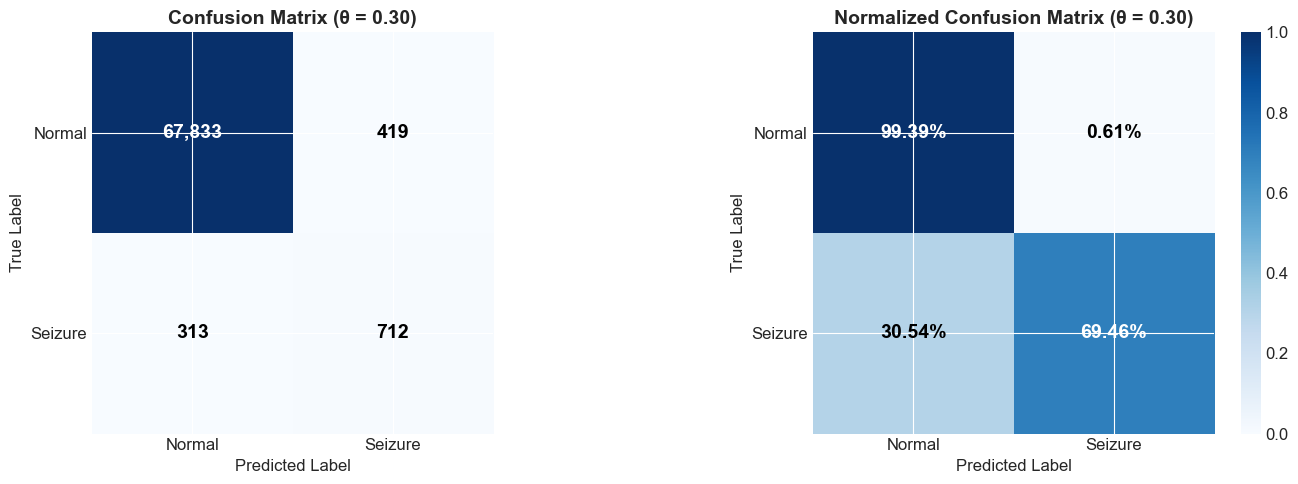

In [11]:
# ── Confusion Matrix ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Confusion matrix at best threshold
cm = np.array([[best['tn'], best['fp']],
               [best['fn'], best['tp']]])

ax = axes[0]
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.set_title(f'Confusion Matrix (θ = {best_thr:.2f})', fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Normal', 'Seizure'])
ax.set_yticklabels(['Normal', 'Seizure'])

# Annotate cells
for i in range(2):
    for j in range(2):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center', color=color, fontsize=14, fontweight='bold')

# Right: Normalized confusion matrix
cm_norm = cm.astype(float)
cm_norm[0] = cm_norm[0] / cm_norm[0].sum() if cm_norm[0].sum() > 0 else 0
cm_norm[1] = cm_norm[1] / cm_norm[1].sum() if cm_norm[1].sum() > 0 else 0

ax2 = axes[1]
im2 = ax2.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
ax2.set_title(f'Normalized Confusion Matrix (θ = {best_thr:.2f})', fontweight='bold')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Normal', 'Seizure'])
ax2.set_yticklabels(['Normal', 'Seizure'])

for i in range(2):
    for j in range(2):
        color = 'white' if cm_norm[i, j] > 0.5 else 'black'
        ax2.text(j, i, f'{cm_norm[i, j]:.2%}', ha='center', va='center', color=color, fontsize=14, fontweight='bold')

plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

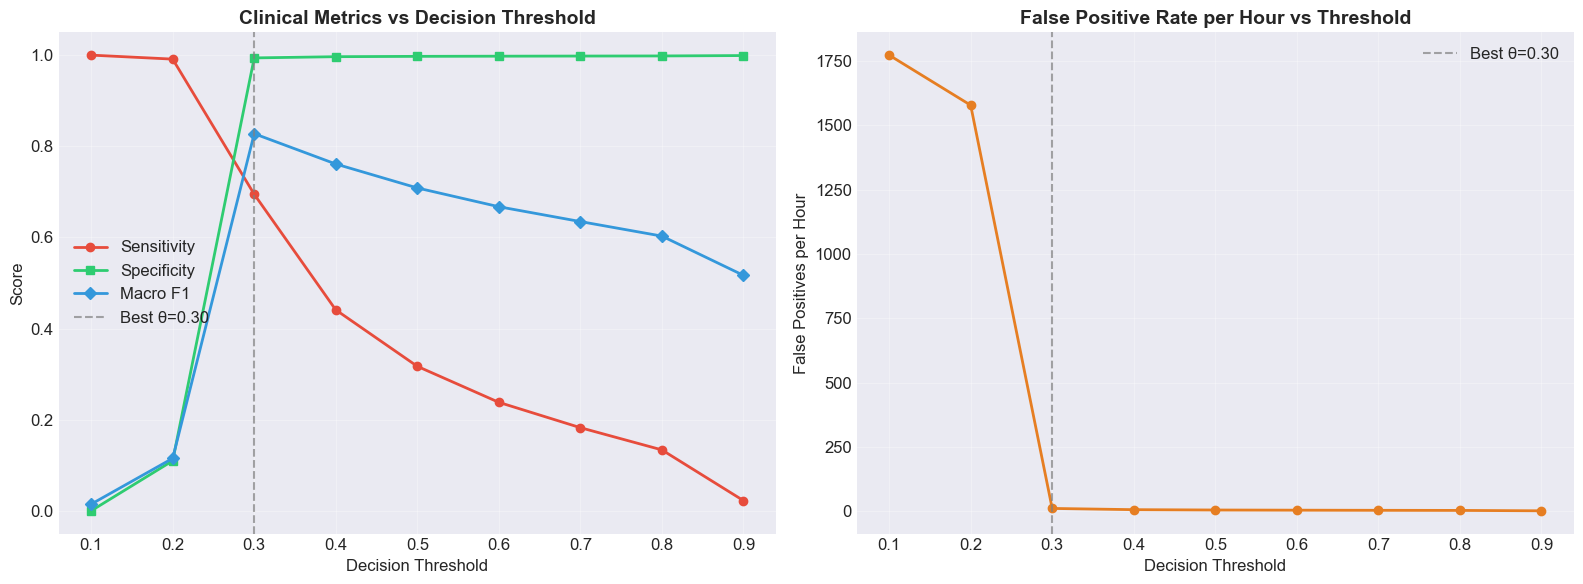

In [12]:
# ── Metrics vs Threshold Curves ──
thrs       = sorted(results.keys())
sens_vals  = [results[t]['sensitivity'] for t in thrs]
spec_vals  = [results[t]['specificity'] for t in thrs]
f1_vals    = [results[t]['macro_f1'] for t in thrs]
fpr_vals   = [results[t]['fpr_per_hour'] for t in thrs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Sensitivity, Specificity, F1 vs Threshold
ax1.plot(thrs, sens_vals,  'o-', color='#e74c3c', linewidth=2, markersize=6, label='Sensitivity')
ax1.plot(thrs, spec_vals,  's-', color='#2ecc71', linewidth=2, markersize=6, label='Specificity')
ax1.plot(thrs, f1_vals,    'D-', color='#3498db', linewidth=2, markersize=6, label='Macro F1')
ax1.axvline(best_thr, color='gray', linestyle='--', alpha=0.7, label=f'Best θ={best_thr:.2f}')
ax1.set_xlabel('Decision Threshold')
ax1.set_ylabel('Score')
ax1.set_title('Clinical Metrics vs Decision Threshold', fontweight='bold')
ax1.set_ylim(-0.05, 1.05)
ax1.legend(loc='center left')
ax1.grid(True, alpha=0.3)

# Right: FPR/h vs Threshold
ax2.plot(thrs, fpr_vals, 'o-', color='#e67e22', linewidth=2, markersize=6)
ax2.axvline(best_thr, color='gray', linestyle='--', alpha=0.7, label=f'Best θ={best_thr:.2f}')
ax2.set_xlabel('Decision Threshold')
ax2.set_ylabel('False Positives per Hour')
ax2.set_title('False Positive Rate per Hour vs Threshold', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

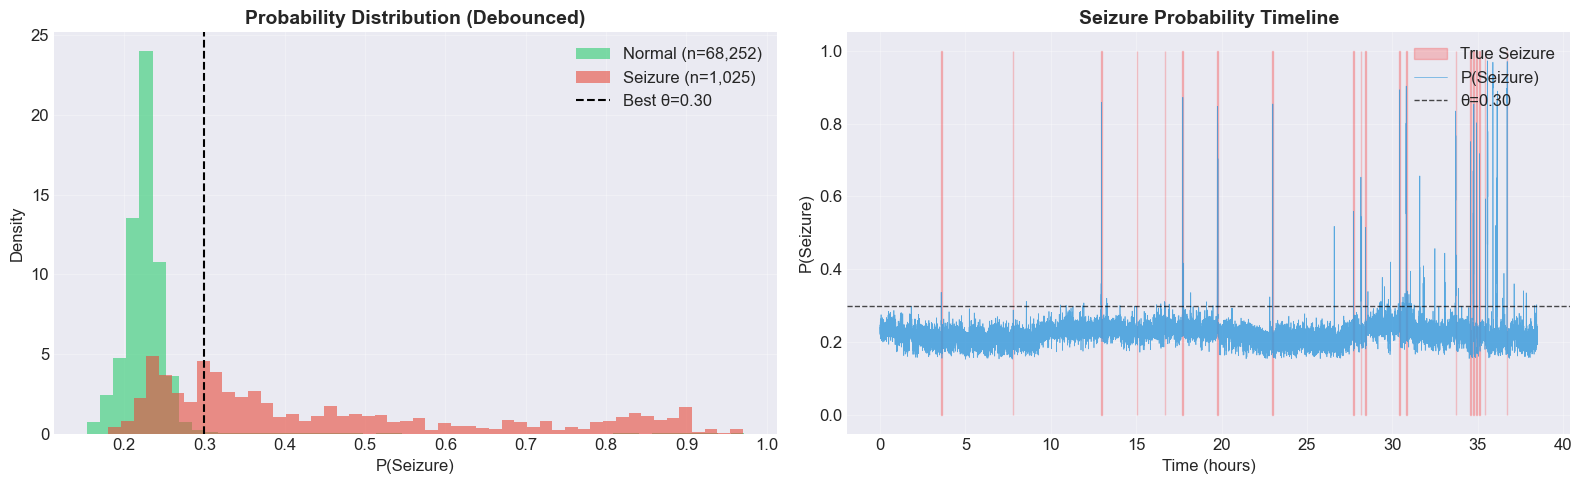

In [13]:
# ── Probability Distribution (Seizure vs Normal) ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

seizure_probs = probs_debounced[labels_arr == 1]
normal_probs  = probs_debounced[labels_arr == 0]

# Histogram
ax1.hist(normal_probs,  bins=50, alpha=0.6, color='#2ecc71', label=f'Normal (n={len(normal_probs):,})', density=True)
ax1.hist(seizure_probs, bins=50, alpha=0.6, color='#e74c3c', label=f'Seizure (n={len(seizure_probs):,})', density=True)
ax1.axvline(best_thr, color='black', linestyle='--', linewidth=1.5, label=f'Best θ={best_thr:.2f}')
ax1.set_xlabel('P(Seizure)')
ax1.set_ylabel('Density')
ax1.set_title('Probability Distribution (Debounced)', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Timeline of probabilities
time_axis = np.arange(len(probs_debounced)) * step_sec / 3600.0
ax2.fill_between(time_axis, 0, 1, where=(labels_arr==1), alpha=0.2, color='red', label='True Seizure')
ax2.plot(time_axis, probs_debounced, color='#3498db', linewidth=0.5, alpha=0.8, label='P(Seizure)')
ax2.axhline(best_thr, color='black', linestyle='--', linewidth=1, alpha=0.7, label=f'θ={best_thr:.2f}')
ax2.set_xlabel('Time (hours)')
ax2.set_ylabel('P(Seizure)')
ax2.set_title('Seizure Probability Timeline', fontweight='bold')
ax2.set_ylim(-0.05, 1.05)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 8. Comparison: Patient-Independent vs Fine-Tuned

Load the **Phase 1 patient-independent model** (`best_model.pth`) and run the same evaluation to compare.

In [14]:
# ── Load Phase 1 (patient-independent) model ──
base_ckpt_path = Path(cfg.training.checkpoint_dir) / 'best_model.pth'
base_ckpt = torch.load(base_ckpt_path, map_location=device, weights_only=True)

base_model = CNN_LSTM_Classifier(
    num_channels     = cfg.model.num_channels,
    sequence_length  = cfg.model.sequence_length,
    num_classes      = cfg.model.num_classes,
    cnn_channels     = cfg.model.cnn_channels,
    kernel_size      = cfg.model.kernel_size,
    lstm_hidden_size = cfg.model.lstm_hidden_size,
    lstm_num_layers  = cfg.model.lstm_num_layers,
    dropout_rate     = cfg.model.dropout_rate,
).to(device)
base_model.load_state_dict(base_ckpt['model_state_dict'])
base_model.eval()

print(f"Phase 1 model loaded from epoch {base_ckpt.get('epoch', '?')}")
print(f"Phase 1 val F1: {base_ckpt.get('metrics', {}).get('f1', 'N/A')}")

Phase 1 model loaded from epoch 7
Phase 1 val F1: 0.2911593435680254


In [15]:
# ── Run Phase 1 inference on the same test set ──
base_probs = []

with torch.no_grad():
    for batch_x, _ in test_loader:
        batch_x = batch_x.to(device)
        logits = base_model(batch_x)
        probs  = F.softmax(logits, dim=1)[:, 1]
        base_probs.extend(probs.cpu().numpy().tolist())

base_probs_arr = median_filter(np.array(base_probs, dtype=np.float32), size=3)

# Compute Phase 1 metrics at the same thresholds
base_results = {}
for thr in THRESHOLDS:
    preds = (base_probs_arr >= thr).astype(np.int64)
    tp = int(((labels_arr == 1) & (preds == 1)).sum())
    tn = int(((labels_arr == 0) & (preds == 0)).sum())
    fp = int(((labels_arr == 0) & (preds == 1)).sum())
    fn = int(((labels_arr == 1) & (preds == 0)).sum())
    
    base_results[thr] = {
        'sensitivity': _safe(calculate_seizure_sensitivity, labels_arr, preds),
        'specificity': _safe(calculate_specificity, labels_arr, preds),
        'macro_f1': _safe(calculate_macro_f1, labels_arr, preds),
        'fpr_per_hour': fp / max(total_hours, 1e-9),
        'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
    }

print('Phase 1 inference complete.')

Phase 1 inference complete.


In [16]:
# ── Side-by-side comparison table ──
print(f"{'='*100}")
print(f"  COMPARISON: Patient-Independent (Phase 1)  vs  Fine-Tuned (Phase 2)  —  Patient {TARGET_PATIENT}")
print(f"{'='*100}")
print(f"  {'Threshold':>10}  |  {'P1 F1':>7}  {'P1 Sens':>8}  {'P1 Spec':>8}  {'P1 FPR/h':>9}  |  {'P2 F1':>7}  {'P2 Sens':>8}  {'P2 Spec':>8}  {'P2 FPR/h':>9}")
print(f"  {'-'*95}")
for thr in sorted(THRESHOLDS):
    b = base_results[thr]
    f = results[thr]
    print(f"  {thr:>10.2f}  |  {b['macro_f1']:>7.4f}  {b['sensitivity']:>8.4f}  {b['specificity']:>8.4f}  {b['fpr_per_hour']:>9.2f}  |  {f['macro_f1']:>7.4f}  {f['sensitivity']:>8.4f}  {f['specificity']:>8.4f}  {f['fpr_per_hour']:>9.2f}")
print(f"{'='*100}")

  COMPARISON: Patient-Independent (Phase 1)  vs  Fine-Tuned (Phase 2)  —  Patient chb15
   Threshold  |    P1 F1   P1 Sens   P1 Spec   P1 FPR/h  |    P2 F1   P2 Sens   P2 Spec   P2 FPR/h
  -----------------------------------------------------------------------------------------------
        0.10  |   0.3985    0.7600    0.5946     718.86  |   0.0146    1.0000    0.0000    1773.37
        0.20  |   0.5504    0.5688    0.9104     158.91  |   0.1151    0.9912    0.1098    1578.65
        0.30  |   0.6250    0.3571    0.9799      35.62  |   0.8276    0.6946    0.9939      10.89
        0.40  |   0.6461    0.2868    0.9908      16.29  |   0.7611    0.4410    0.9966       6.11
        0.50  |   0.6532    0.2576    0.9943      10.08  |   0.7085    0.3171    0.9973       4.81
        0.60  |   0.6449    0.2185    0.9962       6.68  |   0.6673    0.2380    0.9977       4.16
        0.70  |   0.6317    0.1883    0.9970       5.38  |   0.6347    0.1824    0.9979       3.64
        0.80  |   0.59

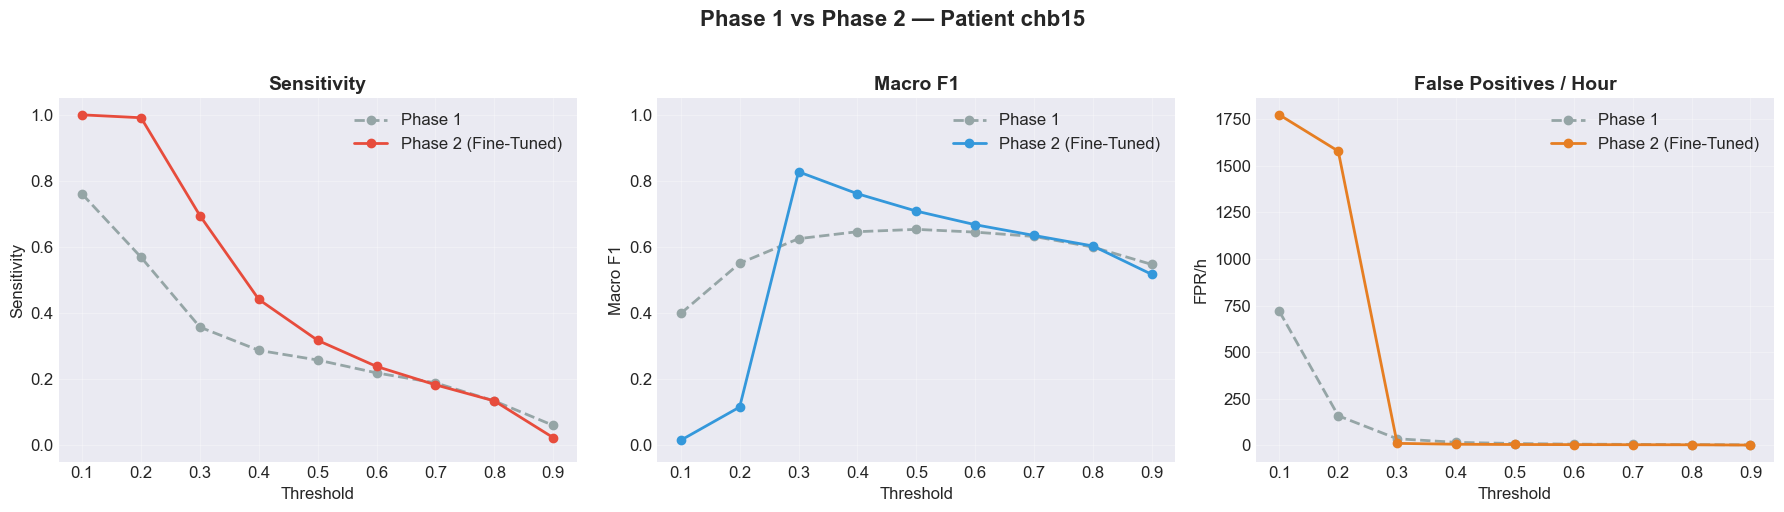

In [17]:
# ── Comparison Visualization ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

base_sens = [base_results[t]['sensitivity'] for t in thrs]
ft_sens   = [results[t]['sensitivity'] for t in thrs]
base_f1   = [base_results[t]['macro_f1'] for t in thrs]
ft_f1     = [results[t]['macro_f1'] for t in thrs]
base_fpr  = [base_results[t]['fpr_per_hour'] for t in thrs]
ft_fpr    = [results[t]['fpr_per_hour'] for t in thrs]

# Sensitivity
axes[0].plot(thrs, base_sens, 'o--', color='#95a5a6', linewidth=2, label='Phase 1')
axes[0].plot(thrs, ft_sens,   'o-',  color='#e74c3c', linewidth=2, label='Phase 2 (Fine-Tuned)')
axes[0].set_title('Sensitivity', fontweight='bold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Sensitivity')
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Macro F1
axes[1].plot(thrs, base_f1, 'o--', color='#95a5a6', linewidth=2, label='Phase 1')
axes[1].plot(thrs, ft_f1,   'o-',  color='#3498db', linewidth=2, label='Phase 2 (Fine-Tuned)')
axes[1].set_title('Macro F1', fontweight='bold')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Macro F1')
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# FPR/h
axes[2].plot(thrs, base_fpr, 'o--', color='#95a5a6', linewidth=2, label='Phase 1')
axes[2].plot(thrs, ft_fpr,   'o-',  color='#e67e22', linewidth=2, label='Phase 2 (Fine-Tuned)')
axes[2].set_title('False Positives / Hour', fontweight='bold')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('FPR/h')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Phase 1 vs Phase 2 — Patient {TARGET_PATIENT}', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Inference Latency Analysis

In [18]:
# ── Latency statistics ──
print(f"{'='*50}")
print(f"  INFERENCE LATENCY (per segment, batched)")
print(f"{'='*50}")
print(f"  Mean     : {latencies_arr.mean():.3f} ms")
print(f"  Median   : {np.percentile(latencies_arr, 50):.3f} ms")
print(f"  P95      : {np.percentile(latencies_arr, 95):.3f} ms")
print(f"  P99      : {np.percentile(latencies_arr, 99):.3f} ms")
print(f"  Max      : {latencies_arr.max():.3f} ms")
print(f"  Throughput: {1000.0 / latencies_arr.mean():.0f} segments/sec")
print(f"{'='*50}")

real_time_ok = latencies_arr.mean() < 500
print(f"\n  Real-time capable (<500ms)? {'✅ YES' if real_time_ok else '❌ NO'}")

  INFERENCE LATENCY (per segment, batched)
  Mean     : 0.023 ms
  Median   : 0.007 ms
  P95      : 0.010 ms
  P99      : 0.022 ms
  Max      : 4.178 ms
  Throughput: 43868 segments/sec

  Real-time capable (<500ms)? ✅ YES


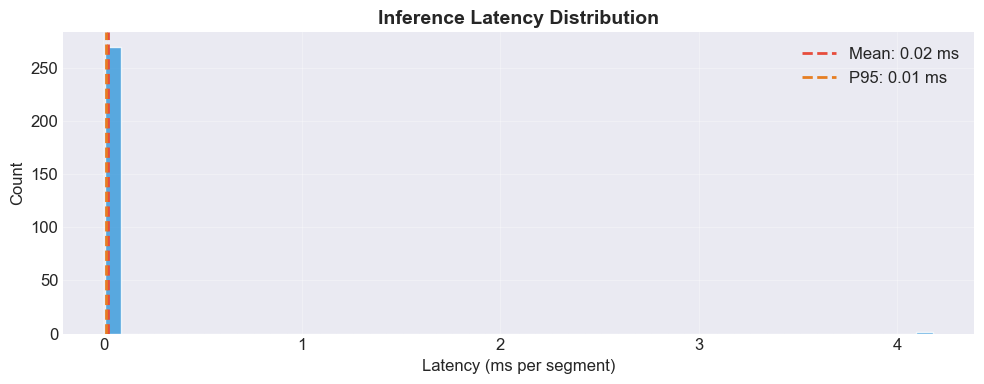

In [19]:
# ── Latency distribution plot ──
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(latencies_arr, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
ax.axvline(latencies_arr.mean(), color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean: {latencies_arr.mean():.2f} ms')
ax.axvline(np.percentile(latencies_arr, 95), color='#e67e22', linestyle='--', linewidth=2, label=f'P95: {np.percentile(latencies_arr, 95):.2f} ms')
ax.set_xlabel('Latency (ms per segment)')
ax.set_ylabel('Count')
ax.set_title('Inference Latency Distribution', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary

This notebook evaluated the **Phase 2 patient-specific fine-tuned model** for patient `chb15`:

- **Checkpoint**: `patient_specific_model.pth` (CNN frozen, LSTM+FC fine-tuned)
- **Test data**: Held-out segments beyond the 1.5h calibration window
- **Normalization**: Z-score via `EEGDataset` (matching Phase 1 training)
- **Post-processing**: Median debounce filter (window=3) for clinical stability
- **Multi-threshold sweep**: Evaluated at 9 thresholds (0.10 — 0.90)
- **Comparison**: Side-by-side with the Phase 1 patient-independent baseline